# Warm primaries: can the SED find the companion?
**Question:** for F-type primaries of 1.2–1.6 solar masses, does an XP + 2MASS fit recover a
main-sequence companion and its mass ratio?

The bundled network covers primaries to 7500 K. Unlike a K or M dwarf, an F star brightens and
cools appreciably on the main sequence, so main-sequence evolution can resemble an unresolved
companion. We first fit emulator mocks with known truth, then Gaia DR3 double-lined binaries (SB2),
where the radial velocities give the mass ratio and, for eclipsing systems, the masses, and finally
ask whether the kinematics of 2200 warm stars within 100 pc follow their single-star or binary ages.
Allow **7 minutes** (the first run downloads 20 SEDs, about 10 s each).

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sedkit import SED, StellarModel, download, fit, plot, query_gaia
from sedkit.plot import BINARY, INK2, OBS, PAPER_STYLE, SINGLE

model = StellarModel()
plt.rcParams.update(PAPER_STYLE)

/Users/jdli/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jdli/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Self-validation on emulator mocks
Truth: coeval pairs of the bundled model at 1.2 Gyr and [M/H] = 0, with primaries of 1.2, 1.4 and
1.55 solar masses (6400, 6900 and 7400 K) and q = 0 (single), 0.3, 0.5, 0.7, 0.85 and 1, at 250 pc.
Measurement errors are the fractional XP and 2MASS errors of an observed G = 9.1 SB2 from part 2.
Each mock adds measurement noise and a draw from the model covariance that the likelihood assumes.
Every mock is fitted twice: with age and [M/H] fixed at the truth, and with both free.

In [2]:
AGE, FEH, PLX, PLX_ERROR = 1.2, 0.0, 4.0, 0.02
template = download('1695777986109779840', cache_dir='data')
fraction = template.error / template.flux
mask = template.fit_mask()
scale = (PLX / 100)**2
rng = np.random.default_rng(2026)
rows, mocks = [], {}
for m1 in (1.2, 1.4, 1.55):
    for q in (0, 0.3, 0.5, 0.7, 0.85, 1.0):
        truth = model.evaluate(m1, q, AGE, FEH)
        flux = truth['flux_10pc'] * scale
        columns, variance = model.error_factors(truth, scale)
        for k in range(3):
            noise = (fraction * flux * rng.normal(size=168) + columns @ rng.normal(size=columns.shape[1])
                     + np.sqrt(variance) * rng.normal(size=168))
            sed = SED(flux + noise, fraction * flux, mask, PLX + PLX_ERROR * rng.normal(), PLX_ERROR)
            mocks[m1, q, k] = sed
            for mode, kw in (('known age', dict(age_gyr=AGE, feh=FEH)), ('free age', dict(age_gyr=None, feh=None))):
                r = fit(sed, fit_parallax=True, model=model, **kw)
                rows.append(dict(m1=m1, q=q, k=k, mode=mode, delta=r['delta'], q_fit=r['binary']['q'],
                                 m1_fit=r['binary']['m1'], age_single=r['single']['age_gyr'],
                                 chi2n_single=r['single']['chi2'] / r['single']['n_fit']))
mock = pd.DataFrame(rows)
print(f"{len(mock)} fits; median per cell:")
print(mock.groupby(['mode', 'm1', 'q'])[['delta', 'q_fit', 'age_single']].median().unstack('mode').round(2).to_string())

108 fits; median per cell:
             delta              q_fit           age_single          
mode      free age known age free age known age   free age known age
m1   q                                                              
1.20 0.00    -0.32     -0.31     0.10      0.10       0.89       1.2
     0.30     3.38      3.80     0.35      0.29       1.68       1.2
     0.50    14.13     76.07     0.50      0.51       4.53       1.2
     0.70     6.95    212.03     0.76      0.72       5.62       1.2
     0.85     1.69    244.30     0.88      0.83       3.55       1.2
     1.00    -0.09    372.48     1.00      1.00       2.70       1.2
1.40 0.00    -0.18     -0.11     0.11      0.10       1.38       1.2
     0.30     0.86      3.13     0.31      0.31       1.29       1.2
     0.50    11.70     48.27     0.66      0.50       1.88       1.2
     0.70     6.87    157.07     0.62      0.69       2.14       1.2
     0.85     1.36    334.12     0.66      0.83       1.96       1.2
     1.

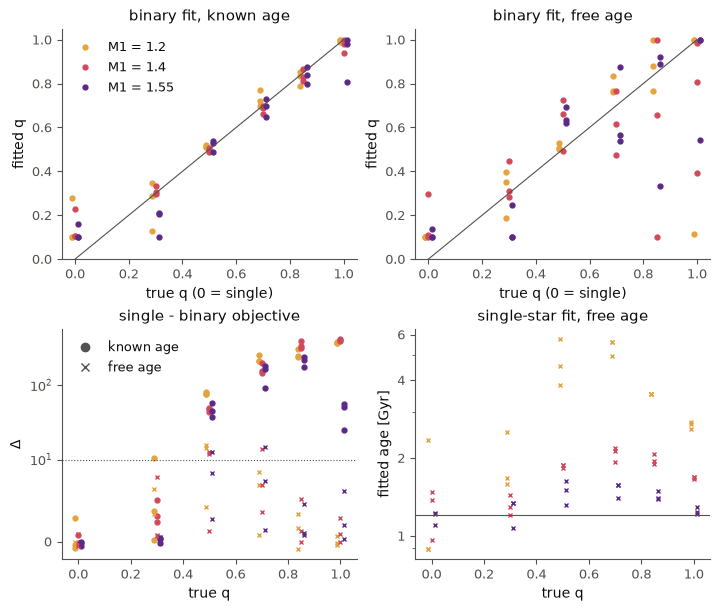

In [3]:
MASS_COLOUR = {1.2: '#e6a23c', 1.4: '#d1495b', 1.55: '#5b2a86'}
fig, axes = plt.subplots(2, 2, figsize=(7.087, 6.0), layout='constrained')
for ax, mode in zip(axes[0], ('known age', 'free age')):
    for m1, g in mock[mock['mode'] == mode].groupby('m1'):
        jitter = (list(MASS_COLOUR).index(m1) - 1) * 0.012
        ax.plot(g.q + jitter, g.q_fit, 'o', ms=3.5, color=MASS_COLOUR[m1], label=f'M1 = {m1}')
    ax.plot([0, 1], [0, 1], color=INK2, lw=.8)
    ax.set(title=f'binary fit, {mode}', xlabel='true q (0 = single)', ylabel='fitted q', xlim=(-.05, 1.05), ylim=(0, 1.05))
ax = axes[1, 0]
for mode, marker in (('known age', 'o'), ('free age', 'x')):
    g = mock[mock['mode'] == mode]
    for m1, h in g.groupby('m1'):
        jitter = (list(MASS_COLOUR).index(m1) - 1) * 0.012
        ax.plot(h.q + jitter, h.delta, marker, ms=3.5, color=MASS_COLOUR[m1])
ax.set_yscale('symlog', linthresh=10)
ax.axhline(10, color=INK2, ls=':', lw=.8)
ax.set(title='single - binary objective', xlabel='true q', ylabel=r'$\Delta$')
ax.plot([], [], 'o', color=INK2, label='known age'); ax.plot([], [], 'x', color=INK2, label='free age')
ax.legend(loc='upper left')
ax = axes[1, 1]
g = mock[mock['mode'] == 'free age']
for m1, h in g.groupby('m1'):
    jitter = (list(MASS_COLOUR).index(m1) - 1) * 0.012
    ax.plot(h.q + jitter, h.age_single, 'x', ms=3.5, color=MASS_COLOUR[m1])
ax.axhline(AGE, color=INK2, lw=.8)
ax.set(title='single-star fit, free age', xlabel='true q', ylabel='fitted age [Gyr]', yscale='log', yticks=[1, 2, 4, 6])
ax.yaxis.set_major_formatter(plt.ScalarFormatter()); ax.yaxis.set_minor_formatter(plt.NullFormatter())
axes[0, 0].legend(loc='upper left');

With the age and [M/H] known, a companion of q ≥ 0.5 raises the objective of the single-star fit by
tens to hundreds and the fitted q follows the truth (medians within 0.03); q = 0.3 companions are
not detected. With the age free, Δ stays below about 15 at every q and the fitted q of individual
mocks scatters over the whole range: the single-star fit absorbs the companion light by moving to an
older, brighter and cooler star (lower right).

## Why age mimics a companion
One noise-free mock, a 1.4 solar-mass primary with a q = 0.7 companion at 1.2 Gyr, against the same
pair with a 0.8 solar-mass primary. Left to right: the colour–magnitude position against single-star
isochrones; the residual of a single star at the true age, a single star at the best-fitting age and
the true binary; and the single-star objective at each assumed age, relative to the true binary.

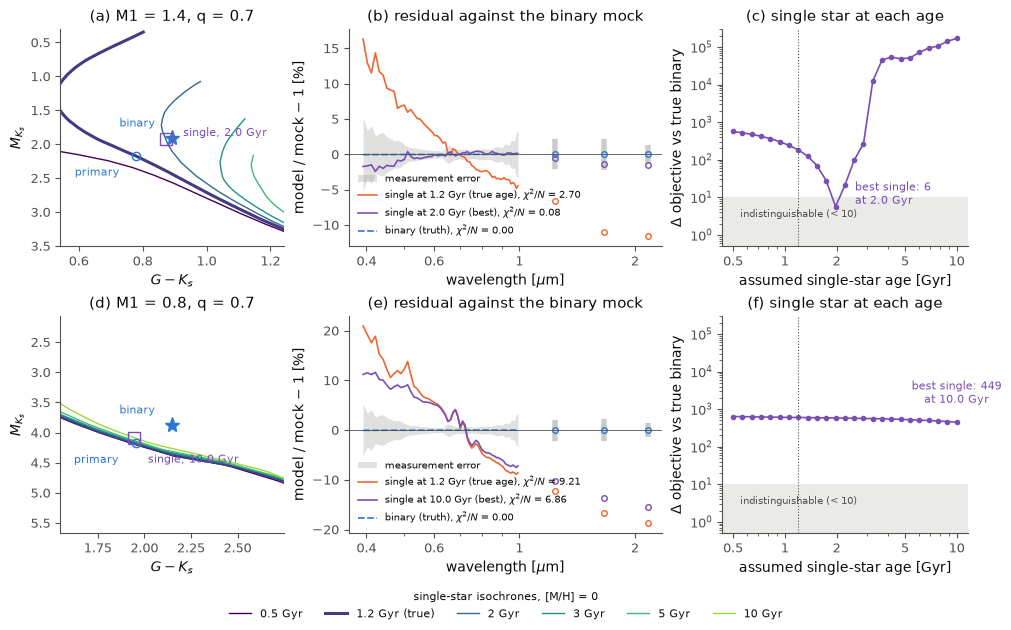

In [4]:
def combined(prediction):
    mks, gks = prediction['labels'][:, 1], prediction['labels'][:, 2]
    add = lambda m: -2.5 * np.log10(np.sum(10**(-0.4 * m)))
    return add(mks + gks) - add(mks), add(mks)

ISOCHRONES = (0.5, 1.2, 2.0, 3.0, 5.0, 10.0)
PROFILE = np.geomspace(0.5, 10, 25)
OLD = '#7a4fb5'
wave = model.wavelength_um
fig, axes = plt.subplots(2, 3, figsize=(10, 6.2), layout='constrained', gridspec_kw=dict(width_ratios=[1, 1.4, 1.1]))
for row, m1, tag in zip(axes, (1.4, 0.8), 'ad'):
    truth = model.evaluate(m1, 0.7, AGE, FEH)
    flux = truth['flux_10pc'] * scale
    sed = SED(flux, fraction * flux, mask, PLX, PLX_ERROR)
    at_age = fit(sed, 'single', fit_parallax=True, age_gyr=AGE, feh=FEH, model=model)
    free = fit(sed, 'single', fit_parallax=True, age_gyr=None, feh=FEH, model=model)
    pair = fit(sed, 'binary', fit_parallax=True, age_gyr=AGE, feh=FEH, model=model)

    ax = row[0]
    for age, colour in zip(ISOCHRONES, plt.cm.viridis(np.linspace(0, .85, len(ISOCHRONES)))):
        labels = model.labels(np.linspace(0.5, 2.2, 400), age, FEH)
        labels[~model.in_domain(labels)] = np.nan
        ax.plot(labels[:, 2], labels[:, 1], color=colour, lw=2.2 if age == AGE else 1,
                label=f'{age:g} Gyr' + (' (true)' if age == AGE else ''))
    primary, system = combined(model.evaluate(m1, 0, AGE, FEH)), combined(truth)
    single = combined(model.evaluate(free['m1'], 0, free['age_gyr'], FEH))
    ax.plot(*primary, 'o', mfc='none', color=BINARY, ms=6)
    ax.plot(*system, '*', color=BINARY, ms=11)
    ax.plot(*single, 's', mfc='none', color=OLD, ms=8)
    ax.annotate('primary', primary, xytext=(-12, -14), textcoords='offset points', ha='right', color=BINARY, fontsize=8)
    ax.annotate('binary', system, xytext=(-12, 8), textcoords='offset points', ha='right', color=BINARY, fontsize=8)
    ax.annotate(f"single, {free['age_gyr']:.1f} Gyr", single, xytext=(12, 2) if m1 > 1 else (10, -18),
                textcoords='offset points', color=OLD, fontsize=8)
    pad = (0.35, 1.6) if m1 > 1 else (0.6, 1.8)
    ax.set(xlim=(system[0] - pad[0], system[0] + pad[0]), ylim=(system[1] + pad[1], system[1] - pad[1]),
           xlabel=r'$G-K_s$', ylabel=r'$M_{K_s}$', title=f'({tag}) M1 = {m1}, q = 0.7')

    ax = row[1]
    error = 100 * fraction
    ax.fill_between(wave[:61], -error[:61], error[:61], color=OBS, alpha=.3, lw=0, label='measurement error')
    ax.errorbar(wave[61:64], np.zeros(3), error[61:64], fmt='none', color=OBS, lw=4, alpha=.5)
    for label, result, colour, ls in ((f'single at {AGE:g} Gyr (true age)', at_age, SINGLE, '-'),
                                      (f"single at {free['age_gyr']:.1f} Gyr (best)", free, OLD, '-'),
                                      ('binary (truth)', pair, BINARY, (0, (4, 1.5)))):
        residual = 100 * (result['flux'] / flux - 1)
        ax.plot(wave[:61], residual[:61], color=colour, ls=ls,
                label=f"{label}, $\chi^2/N$ = {result['chi2'] / result['n_fit']:.2f}")
        ax.plot(wave[61:64], residual[61:64], 'o', mfc='none', color=colour, ms=4)
    ax.axhline(0, color=INK2, lw=.6)
    ax.set(xscale='log', xlabel=r'wavelength [$\mu$m]', ylabel='model / mock − 1 [%]',
           title=f'({chr(ord(tag) + 1)}) residual against the binary mock')
    ax.set_xticks([0.4, 0.6, 1, 2]); ax.set_xticklabels(['0.4', '0.6', '1', '2'])
    ax.legend(loc='lower left', fontsize=7)

    ax = row[2]
    profile = []
    for age in PROFILE:
        try:
            profile.append(fit(sed, 'single', fit_parallax=True, age_gyr=age, feh=FEH, model=model)['objective'] - pair['objective'])
        except ValueError:
            profile.append(np.nan)
    profile = np.array(profile)
    best = np.nanargmin(profile)
    ax.axhspan(0.5, 10, color=OBS, alpha=.2, lw=0)
    ax.text(0.55, 3, 'indistinguishable (< 10)', fontsize=7, color=INK2)
    ax.plot(PROFILE, profile, '-o', ms=3, color=OLD)
    ax.axvline(AGE, color=INK2, ls=':', lw=.8)
    ax.annotate(f'best single: {profile[best]:.0f}\nat {PROFILE[best]:.1f} Gyr', (PROFILE[best], profile[best]),
                xytext=(14, 2) if m1 > 1 else (0, 14), textcoords='offset points',
                ha='left' if m1 > 1 else 'center', color=OLD, fontsize=8)
    ax.set(xscale='log', yscale='log', ylim=(0.5, 3e5), xlabel='assumed single-star age [Gyr]',
           ylabel=r'$\Delta$ objective vs true binary', title=f'({chr(ord(tag) + 2)}) single star at each age')
    ax.set_xticks([0.5, 1, 2, 5, 10]); ax.set_xticklabels(['0.5', '1', '2', '5', '10'])
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc='outside lower center', ncol=len(ISOCHRONES),
           title='single-star isochrones, [M/H] = 0', fontsize=8, title_fontsize=8);

The warm binary sits on the 2 Gyr single-star isochrone: a single 1.4 solar-mass star 0.8 Gyr older
has the same luminosity and colour, and its SED matches the binary within the errors (Δ ≈ 6).
A K dwarf hardly evolves in 10 Gyr, so no single star reaches the binary (Δ ≈ 450 at best).
For warm primaries, XP + 2MASS alone do not separate a companion from main-sequence evolution;
the binary signal needs an age constraint.

How good must that age be? The same mocks fitted at an age 25 per cent too young or too old:

In [5]:
rows = []
for (m1, q, k), sed in mocks.items():
    if q not in (0, 0.7):
        continue
    for label, age in (('0.8 x age', AGE / 1.25), ('1.25 x age', AGE * 1.25)):
        r = fit(sed, fit_parallax=True, model=model, age_gyr=age, feh=FEH)
        rows.append(dict(m1=m1, q=q, assumed=label, delta=r['delta'], q_fit=r['binary']['q']))
wrong = pd.DataFrame(rows)
print(wrong.groupby(['assumed', 'q', 'm1'])[['delta', 'q_fit']].median().round(2).unstack('m1').to_string())

                 delta                  q_fit            
m1                1.20    1.40     1.55  1.20  1.40  1.55
assumed    q                                             
0.8 x age  0.0   -0.07    4.02    40.24  0.10  0.33  0.51
           0.7  237.08  261.56  5307.96  0.73  0.73  0.80
1.25 x age 0.0   -0.61   -1.08    -2.25  0.10  0.10  0.10
           0.7  182.10   60.83     7.82  0.70  0.60  0.38


At 1.2–1.4 solar masses a 25 per cent age error keeps singles and q = 0.7 binaries apart, with the
fitted q biased by up to 0.1. At 1.55 solar masses, near the end of the main sequence at this age,
an age that is too young turns single stars into binaries (Δ ≈ 40) and an age that is too old
hides q = 0.7 companions (Δ ≈ 8, fitted q ≈ 0.4).

## 2. Observed Gaia DR3 SB2s
Selection: Gaia DR3 SB2 orbits with XP spectra, BP−RP 0.3–0.5 (primaries of about 6800–7400 K),
G > 8, RUWE < 1.4, within 333 pc and at |b| > 30° so that extinction is small (sedkit fixes it to
zero). The mass ratio is $q_{RV} = K_{min}/K_{max}$; Gaia's "primary" is not always the more
massive star. For eclipsing systems (Gaia DR3 eclipsing-binary table) $\sin i \approx 1$, so
$M\sin^3 i$ from the orbit is close to the dynamical mass.

In [6]:
QUERY = """SELECT n.source_id, n.period, n.eccentricity,
  n.semi_amplitude_primary AS k1, n.semi_amplitude_primary_error AS k1_error,
  n.semi_amplitude_secondary AS k2, n.semi_amplitude_secondary_error AS k2_error,
  g.parallax, g.phot_g_mean_mag, g.bp_rp, g.ruwe, v.model_type
FROM gaiadr3.nss_two_body_orbit AS n
JOIN gaiadr3.gaia_source AS g ON g.source_id = n.source_id
LEFT OUTER JOIN gaiadr3.vari_eclipsing_binary AS v ON v.source_id = n.source_id
WHERE n.nss_solution_type = 'SB2' AND g.has_xp_continuous = 'true'
  AND g.parallax > 3 AND ABS(g.b) > 30 AND g.phot_g_mean_mag > 8
  AND g.bp_rp BETWEEN 0.3 AND 0.5 AND g.ruwe < 1.4"""
sb2 = query_gaia(QUERY, cache_dir='data/warm_sb2', tap='ari').to_pandas()
sb2['eclipsing'] = sb2.model_type.fillna('').str.len() > 0
k_max, k_min = np.maximum(sb2.k1, sb2.k2), np.minimum(sb2.k1, sb2.k2)
sb2['q_rv'] = k_min / k_max
# M sin^3 i [Msun] of the more massive star; K in km/s, P in days.
sb2['m1_sin3i'] = 1.036149e-7 * (1 - sb2.eccentricity**2)**1.5 * (sb2.k1 + sb2.k2)**2 * k_max * sb2.period
sb2 = sb2.sort_values('bp_rp').reset_index(drop=True)
print(f"{len(sb2)} SB2s, {sb2.eclipsing.sum()} eclipsing")
print(sb2[['source_id', 'period', 'q_rv', 'm1_sin3i', 'eclipsing', 'phot_g_mean_mag', 'bp_rp', 'parallax']].round(3).to_string(index=False))

20 SB2s, 4 eclipsing
          source_id  period  q_rv  m1_sin3i  eclipsing  phot_g_mean_mag  bp_rp  parallax
4571651872348064896   4.770 0.994     1.796       True            8.444  0.343     3.341
1695777986109779840   4.650 0.995     0.567      False            9.078  0.370     3.557
1348044175263408384   2.060 0.890     1.671       True            8.052  0.386     5.889
6184313724360509056   0.735 0.838     0.017      False            9.108  0.392     3.156
4843795607407259136   3.069 0.779     0.937      False            8.928  0.406     4.130
1199799702549770112   3.451 0.966     1.039      False            8.072  0.430     4.253
1639888130739606784   0.629 0.994     0.093      False            8.475  0.432     4.849
4755736614491740416   0.727 0.819     0.033      False            8.999  0.435     3.501
6530442871002371712   3.281 0.994     1.253      False            9.182  0.457     3.867
1718177928481690624   9.681 0.891     1.336      False            9.207  0.457     4.051


Each SED is fitted as in part 1 with age and [M/H] free (field stars), and once more as a binary
with q fixed at $q_{RV}$. The RV values are a check, not inputs, except in that second fit.

In [7]:
%%time
rows, fits = [], {}
for _, s in sb2.iterrows():
    sed = download(str(s.source_id), cache_dir='data')
    r = fit(sed, fit_parallax=True, age_gyr=None, feh=None, model=model)
    at_rv = fit(sed, 'binary', fit_parallax=True, age_gyr=None, feh=None, q=s.q_rv, model=model)
    fits[s.source_id] = sed, r, at_rv
    b = r['binary']
    rows.append(dict(source_id=s.source_id, delta=r['delta'], q_sed=b['q'], m1_free=b['m1'],
                     m1_at_rv=at_rv['m1'], age_at_rv=at_rv['age_gyr'], feh_at_rv=at_rv['feh'],
                     chi2n_single=r['single']['chi2'] / r['single']['n_fit'],
                     chi2n_at_rv=at_rv['chi2'] / at_rv['n_fit'],
                     d_objective=at_rv['objective'] - min(b['objective'], r['single']['objective'])))
obs = sb2.merge(pd.DataFrame(rows), on='source_id')
obs['teff1'] = [model.labels([m], a, z)[0, 0] for m, a, z in zip(obs.m1_at_rv, obs.age_at_rv, obs.feh_at_rv)]
print(obs[['source_id', 'q_rv', 'q_sed', 'delta', 'chi2n_single', 'chi2n_at_rv', 'd_objective',
           'm1_at_rv', 'm1_sin3i', 'age_at_rv']].round(2).to_string(index=False))

          source_id  q_rv  q_sed  delta  chi2n_single  chi2n_at_rv  d_objective  m1_at_rv  m1_sin3i  age_at_rv
4571651872348064896  0.99   0.25   0.71          2.56         2.60         3.56      1.71      1.80       1.30
1695777986109779840  0.99   1.00   1.41          0.91         0.89         0.00      1.48      0.57       1.19
1348044175263408384  0.89   1.00   0.68          1.18         1.19         1.38      1.56      1.67       1.15
6184313724360509056  0.84   0.82   3.42          1.02         0.97         0.05      1.66      0.02       1.32
4843795607407259136  0.78   0.97   0.08          1.11         1.13         1.68      1.58      0.94       1.24
1199799702549770112  0.97   0.57   4.17          1.61         1.58         1.77      1.68      1.04       1.44
1639888130739606784  0.99   0.10  -0.22          0.66         0.68         1.11      1.49      0.09       1.30
4755736614491740416  0.82   1.00   8.66          1.27         1.15         1.03      1.61      0.03       1.54
6

eclipsing: M1 sin^3 i / SED M1 = [1.05 1.07 0.8  1.1 ]


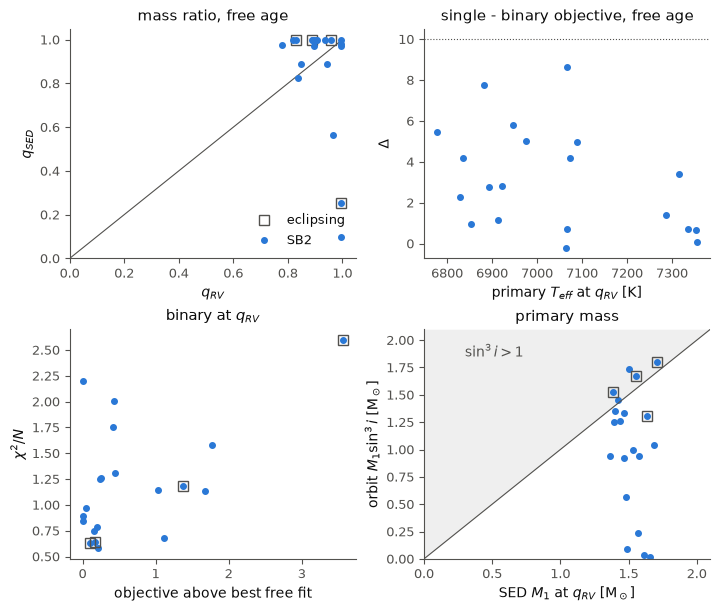

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(7.087, 6.0), layout='constrained')
eb = obs.eclipsing
ax = axes[0, 0]
ax.errorbar(obs.q_rv, obs.q_sed, fmt='o', ms=4, color=BINARY, label='SB2')
ax.plot(obs.q_rv[eb], obs.q_sed[eb], 's', ms=7, mfc='none', color=INK2, label='eclipsing')
ax.plot([0, 1], [0, 1], color=INK2, lw=.8)
ax.set(title='mass ratio, free age', xlabel=r'$q_{RV}$', ylabel=r'$q_{SED}$', xlim=(0, 1.05), ylim=(0, 1.05))
ax.legend(loc='lower right')
ax = axes[0, 1]
ax.plot(obs.teff1, obs.delta, 'o', ms=4, color=BINARY)
ax.axhline(10, color=INK2, ls=':', lw=.8)
ax.set(title='single - binary objective, free age', xlabel=r'primary $T_{eff}$ at $q_{RV}$ [K]', ylabel=r'$\Delta$')
ax = axes[1, 0]
ax.plot(obs.d_objective, obs.chi2n_at_rv, 'o', ms=4, color=BINARY)
ax.plot(obs.d_objective[eb], obs.chi2n_at_rv[eb], 's', ms=7, mfc='none', color=INK2)
ax.set(title=r'binary at $q_{RV}$', xlabel='objective above best free fit', ylabel=r'$\chi^2/N$')
ax = axes[1, 1]
lim = (0, 2.1)
ax.fill_between(lim, lim, lim[1], color=OBS, alpha=.15, lw=0)
ax.text(.3, 1.85, r'$\sin^3 i > 1$', color=INK2)
ax.plot(obs.m1_at_rv, obs.m1_sin3i, 'o', ms=4, color=BINARY)
ax.plot(obs.m1_at_rv[eb], obs.m1_sin3i[eb], 's', ms=7, mfc='none', color=INK2)
ax.plot(lim, lim, color=INK2, lw=.8)
ax.set(title='primary mass', xlabel=r'SED $M_1$ at $q_{RV}$ [M$_\odot$]', ylabel=r'orbit $M_1\sin^3 i$ [M$_\odot$]', xlim=lim, ylim=lim)
ratio = obs.m1_sin3i[eb] / obs.m1_at_rv[eb]
print('eclipsing: M1 sin^3 i / SED M1 =', np.round(ratio.to_numpy(), 2))

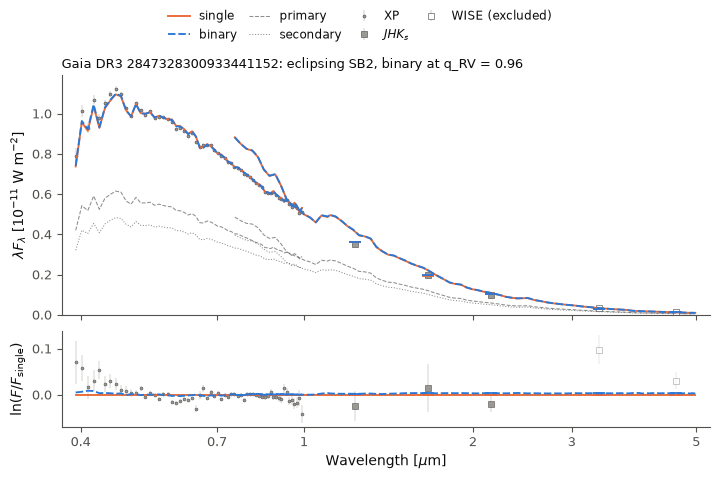

In [9]:
best = obs[eb].sort_values('d_objective').iloc[0]
sed, r, at_rv = fits[best.source_id]
plot(sed, {'single': r['single'], 'binary': at_rv},
     title=f"Gaia DR3 {best.source_id}: eclipsing SB2, binary at q_RV = {best.q_rv:.2f}");

## 3. Kinematics: which age do warm stars follow?
Disc stars heat vertically with age, so their vertical action $J_z$ grows with age. A single star
should follow its single-star age $\tau_s$; a binary whose companion made it look older should follow
the younger age $\tau_b$ of its binary solution. `warm_jz_100pc.csv` holds 2268 Gaia DR3 stars within
100 pc with RVs, BP−RP 0.25–0.60 and XP spectra: $J_z$ in MilkyWayPotential2022 from the Gaia
astrometry and RVs, the Gaia `non_single_star` flag, and the $\tau_s$, $\tau_b$ of the `fit` call used
above (age free, [M/H] free or 0; J-CAPS experiment `warm_jz_test_20261003`). Stars brighter than
G = 5, where the fits degrade, are left out. The local $J_z$ distribution has a thick-disc tail, so the
statistics are medians and Spearman rank correlations with bootstrap intervals.

no NSS flag          [M/H] free n=2031 delta rho = -0.078 (95%: -0.137 to -0.022)
no NSS flag          [M/H] = 0  n=2031 delta rho = -0.081 (95%: -0.131 to -0.034)
NSS flag             [M/H] free n= 179 delta rho = +0.180 (95%: -0.001 to +0.327)
NSS flag             [M/H] = 0  n= 179 delta rho = +0.171 (95%: +0.015 to +0.330)
no flag, |b| < 30°   [M/H] free n=1103 delta rho = -0.064 (95%: -0.133 to +0.003)
no flag, |b| < 30°   [M/H] = 0  n=1103 delta rho = -0.072 (95%: -0.133 to -0.001)


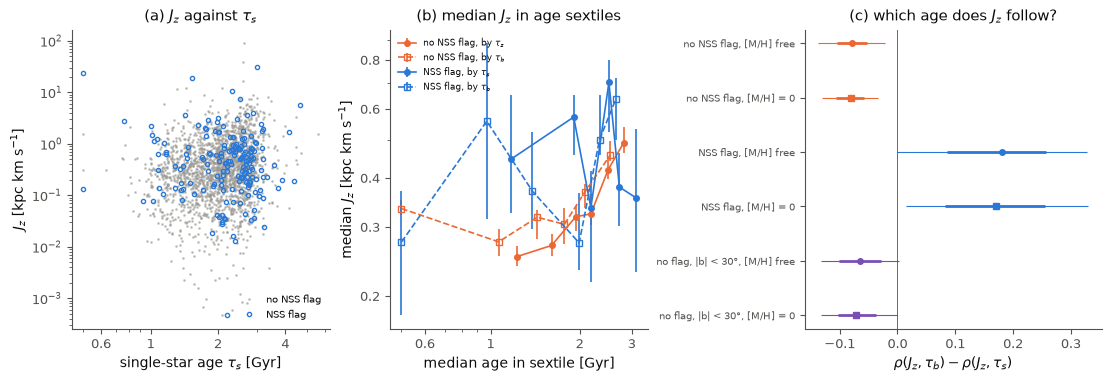

In [10]:
from scipy.stats import spearmanr

jz = pd.read_csv('warm_jz_100pc.csv')
jz = jz[jz.phot_g_mean_mag >= 5]
groups = {'no NSS flag': jz[jz.non_single_star == 0], 'NSS flag': jz[jz.non_single_star > 0],
          'no flag, |b| < 30°': jz[(jz.non_single_star == 0) & (jz.b.abs() < 30)]}
GROUP_COLOUR = {'no NSS flag': SINGLE, 'NSS flag': BINARY, 'no flag, |b| < 30°': OLD}

def delta_rho(g, tag, n_boot=500):
    j, ts, tb = g.Jz.to_numpy(), g['single_age' + tag].to_numpy(), g['binary_age' + tag].to_numpy()
    one = lambda i: spearmanr(j[i], tb[i])[0] - spearmanr(j[i], ts[i])[0]
    boot = [one(rng.integers(0, len(j), len(j))) for _ in range(n_boot)]
    return one(np.arange(len(j))), np.percentile(boot, [2.5, 16, 84, 97.5])

def sextile_medians(g, column):
    edges = np.quantile(g[column], np.linspace(0, 1, 7)); edges[-1] += 1e-9
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        h = g[(g[column] >= lo) & (g[column] < hi)].Jz.to_numpy()
        boot = [np.median(h[rng.integers(0, len(h), len(h))]) for _ in range(500)]
        rows.append((np.median(g[column][(g[column] >= lo) & (g[column] < hi)]), np.median(h), *np.percentile(boot, [16, 84])))
    return np.array(rows)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.7), layout='constrained', gridspec_kw=dict(width_ratios=[1, 1, 1.15]))
ax = axes[0]
plain, flagged = groups['no NSS flag'], groups['NSS flag']
ax.plot(plain.single_age, plain.Jz, '.', ms=2, color=OBS, alpha=.5, label='no NSS flag')
ax.plot(flagged.single_age, flagged.Jz, 'o', ms=3, mfc='none', color=BINARY, label='NSS flag')
ax.set(xscale='log', yscale='log', xlabel=r'single-star age $\tau_s$ [Gyr]', ylabel=r'$J_z$ [kpc km s$^{-1}$]',
       title=r'(a) $J_z$ against $\tau_s$')
ax.set_xticks([0.6, 1, 2, 4]); ax.set_xticklabels(['0.6', '1', '2', '4']); ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.legend(loc='lower right', fontsize=7)
ax = axes[1]
for name in ('no NSS flag', 'NSS flag'):
    for column, ls, marker, label in (('single_age', '-', 'o', r'by $\tau_s$'), ('binary_age', '--', 's', r'by $\tau_b$')):
        m = sextile_medians(groups[name], column)
        ax.errorbar(m[:, 0], m[:, 1], [m[:, 1] - m[:, 2], m[:, 3] - m[:, 1]], fmt=marker, ls=ls, ms=4,
                    mfc=GROUP_COLOUR[name] if ls == '-' else 'none', color=GROUP_COLOUR[name], label=f'{name}, {label}')
ax.set(xscale='log', yscale='log', xlabel='median age in sextile [Gyr]', ylabel=r'median $J_z$ [kpc km s$^{-1}$]',
       title=r'(b) median $J_z$ in age sextiles')
for axis, ticks in ((ax.xaxis, [0.6, 1, 2, 3]), (ax.yaxis, [0.2, 0.3, 0.4, 0.6, 0.8])):
    axis.set_ticks(ticks); axis.set_ticklabels([f'{v:g}' for v in ticks]); axis.set_minor_formatter(plt.NullFormatter())
ax.legend(loc='upper left', fontsize=6.5)
ax = axes[2]
rows = [(name, tag) for name in groups for tag in ('', '_feh0')]
for i, (name, tag) in enumerate(rows):
    value, (p2, p16, p84, p97) = delta_rho(groups[name], tag)
    ax.errorbar(value, i, xerr=[[value - p2], [p97 - value]], fmt='none', color=GROUP_COLOUR[name], lw=.8)
    ax.errorbar(value, i, xerr=[[value - p16], [p84 - value]], fmt='o' if tag == '' else 's', color=GROUP_COLOUR[name], lw=2, ms=4)
    print(f"{name:20s} {'[M/H] free' if tag == '' else '[M/H] = 0':10s} n={len(groups[name]):4d} delta rho = {value:+.3f} "
          f"(95%: {p2:+.3f} to {p97:+.3f})")
ax.axvline(0, color=INK2, lw=.6)
ax.set(yticks=range(len(rows)), yticklabels=[f"{n}, {'[M/H] free' if t == '' else '[M/H] = 0'}" for n, t in rows],
       xlabel=r'$\rho(J_z, \tau_b) - \rho(J_z, \tau_s)$', title=r'(c) which age does $J_z$ follow?')
ax.tick_params(axis='y', labelsize=7)
ax.invert_yaxis();

For stars without a Gaia binary flag, the median $J_z$ rises steadily with $\tau_s$ (0.25 to
0.49 kpc km s$^{-1}$ from 1.2 to 2.8 Gyr), as the age–velocity-dispersion relation predicts, and
$J_z$ ranks better by $\tau_s$ than by $\tau_b$ (Δρ < 0, also for the |b| < 30° stars whose
$v_z$ rests on proper motions). These stars behave as singles. For the 179 flagged binaries
$J_z$ does not follow $\tau_s$ but does follow $\tau_b$ (Δρ ≈ +0.18, about 2σ): the companion
that makes a warm binary look older as a single star is visible in its kinematics.

## What this tells us
- The warm network describes these composite SEDs: single and binary fits reach $\chi^2/N$ of
  0.6–2.6, and binaries with q fixed at the RV value lie within 4 of the best free objective.
- With the age free, the observed Δ and $q_{SED}$ behave as in the free-age mocks: small Δ and a
  fitted q that does not track $q_{RV}$. This is the age degeneracy of part 1, not a model failure.
- For three of the four eclipsing SB2s, $M_1\sin^3 i$ is 1.05–1.10 times the SED primary mass at
  $q_{RV}$: with $\sin i \approx 1$ the SED mass is 5–10 per cent low. The fourth, a 1.6-day
  system with ellipsoidal variation, gives 0.80, which requires $i \approx 68°$ or a SED mass
  25 per cent high. The absolute mass scale at 6800–7400 K holds to about 10 per cent.
- Vertical actions follow the single-star ages of warm stars without a binary flag and the
  binary-solution ages of flagged binaries. $J_z$ is too broad at fixed age to be an age prior for
  one star; it tests the degeneracy for a population.

## Scope
Twenty SB2s, four eclipsing, mostly near-twins ($q_{RV}$ 0.78–1): SB2 detection favours bright
companions, so the low-q behaviour rests on the mocks. Mocks use the model itself as truth and
check the fitting, not the network. Extinction is zero, and orbital inclinations of the eclipsing
systems are taken as 90°. Primaries above 7500 K and evolved stars are outside the model. The
kinematic test uses DR3 RVs, which for binaries can include orbital motion, and τ_b from free-q fits;
its Δρ is not a binary-fraction estimate.

**Discussion:** how would the SED age profiles and $J_z$ enter one hierarchical model for the
binary fraction of warm stars?

Back: [fit an observed SED](01_sed_fit.ipynb) · [Gaia orbit, hidden twin](02_gaia_orbit_twin.ipynb)